In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_glw = pd.read_csv("glw.csv")
df_glw["class"] = "GLWa"
df_rpa = pd.read_csv("rpa.csv")
df_rpa["class"] = "RPa"
df_wt = pd.read_csv("wt.csv")
df_wt["class"] = "Wild Type"
df = pd.concat([df_glw, df_rpa, df_wt])
df.head()

,id,mean_width_microns,mean_height_microns,avg_direction_radians,avg_speed_mps,total_distance_microns,distance_change_microns,min_width_microns,max_width_microns,min_height_microns,max_height_microns,spiral_score,class
0,0,265.433177,269.122358,2.846161,655.001901,39256.447245,186.550261,214.285714,364.285714,170.011806,340.023613,122.274206,GLWa
1,1,217.978242,220.901944,2.001472,363.321426,21775.064151,441.387018,192.857143,300.000000,191.263282,297.520661,104.179918,GLWa
2,2,271.234019,269.772069,2.775141,610.394335,36582.967119,408.963629,214.285714,342.857143,212.514758,340.023613,126.934186,GLWa
3,3,234.737553,236.471397,2.788281,603.282548,36156.734015,100.001250,192.857143,321.428571,212.514758,297.520661,121.388718,GLWa
4,4,253.188279,257.900066,2.745678,516.200410,30937.611222,52.690132,214.285714,342.857143,212.514758,361.275089,109.507950,GLWa


<Axes: xlabel='total_distance_microns', ylabel='Density'>

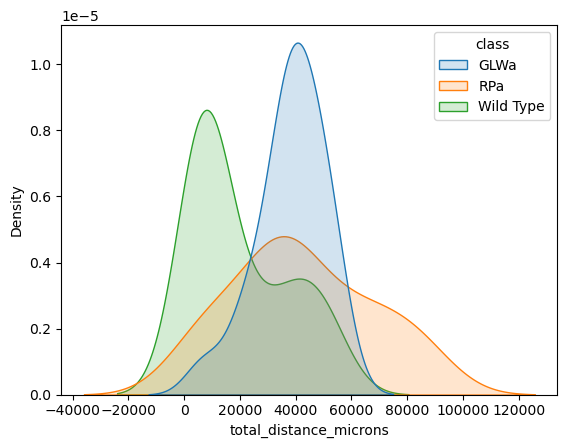

In [3]:
sns.kdeplot(data = df, x = "total_distance_microns", hue = "class", fill = True, alpha = 0.2)

<Axes: xlabel='mean_width_microns', ylabel='Density'>

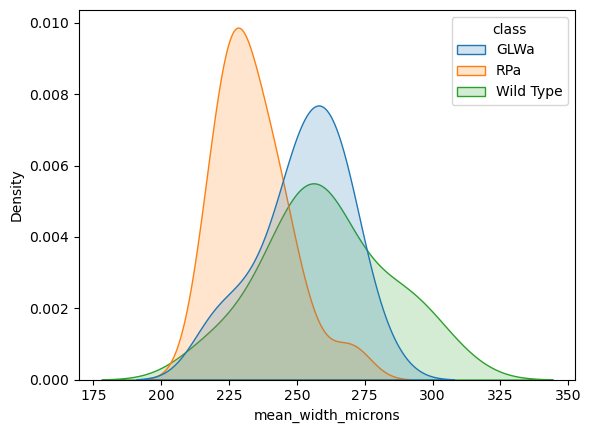

In [4]:
sns.kdeplot(data = df, x = "mean_width_microns", hue = "class", fill = True, alpha = 0.2)

<Axes: xlabel='mean_height_microns', ylabel='Density'>

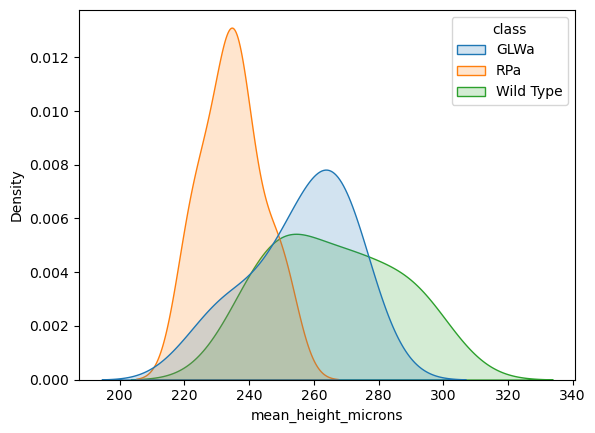

In [5]:
sns.kdeplot(data = df, x = "mean_height_microns", hue = "class", fill = True, alpha = 0.2)

In [6]:
import umap
reducer = umap.UMAP()

df_reduced = df.filter(items = ["mean_width_microns", "mean_height_microns", 
                                "avg_direction_radians", "avg_speed_mps", 
                                "total_distance_microns", "distance_change_microns",
                                "min_width_microns", "max_width_microns",
                                "min_height_microns", "max_heigh_microns"])
embedding = reducer.fit_transform(df_reduced)
embedding.shape

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


(60, 2)

In [7]:
embedding

array([[-1.2397584e+00,  5.8523312e+00],
       [-6.4471631e+00,  4.9803147e+00],
       [-2.9677825e+00,  5.1932936e+00],
       [-3.0971801e+00,  5.3274517e+00],
       [-4.8942008e+00,  5.0651855e+00],
       [-3.0538149e+00,  4.9355588e+00],
       [-5.3665714e+00,  4.9870605e+00],
       [ 5.2328247e-01,  6.3385901e+00],
       [ 1.4052070e+00,  7.0076432e+00],
       [-8.4299755e-01,  6.0298877e+00],
       [ 1.5671576e+00,  6.8070250e+00],
       [ 9.3541646e-01,  6.5718832e+00],
       [-3.1147221e-01,  6.0984116e+00],
       [-6.7018976e+00,  5.0114694e+00],
       [-8.1094497e-01,  6.4195681e+00],
       [ 1.7625203e+00,  6.4535055e+00],
       [-9.5559559e+00,  4.7775970e+00],
       [-4.0858040e+00,  5.1240096e+00],
       [-2.6092547e-01,  6.4460573e+00],
       [ 1.9023726e+00,  6.6240025e+00],
       [-4.7992859e+00,  4.8399949e+00],
       [-8.8850183e+00,  4.8297844e+00],
       [ 2.4503517e+00,  5.8795099e+00],
       [-8.9636860e+00,  5.0970540e+00],
       [-3.18877

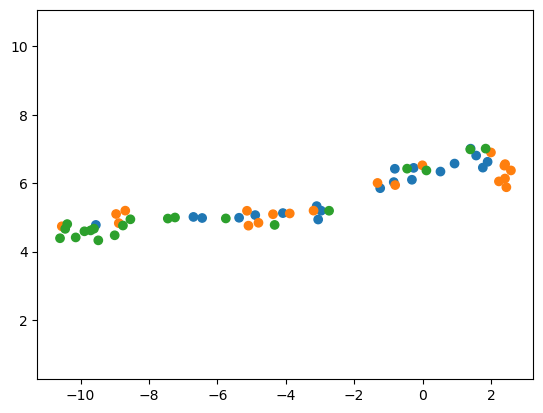

In [8]:
plt.scatter(embedding[:, 0], embedding[:, 1],
    c=[sns.color_palette()[x] for x in df["class"].map({"GLWa":0, "RPa":1, "Wild Type":2})])
plt.gca().set_aspect('equal', 'datalim')

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(df_reduced)

PCA(n_components=2)

In [10]:
print(pca.explained_variance_ratio_)
print(pca.singular_values_)

[9.99918990e-01 7.48320717e-05]
[160873.87110866   1391.70436258]


In [11]:
df_pca = pca.transform(df_reduced)

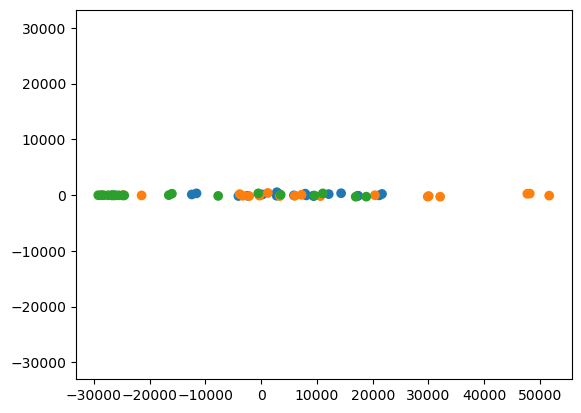

In [12]:
plt.scatter(df_pca[:, 0], df_pca[:, 1],
    c=[sns.color_palette()[x] for x in df["class"].map({"GLWa":0, "RPa":1, "Wild Type":2})])
plt.gca().set_aspect('equal', 'datalim')

## Travelers vs Spiralers vs Nonmovers

Here, I define a traveler as moving more than 200 microns (0.2mm, or around 10 pixels) from its starting point. If not a traveler, a spiraler travels more than 20000 total microns. If neither of those, it's a nonmover.

In [16]:
movement_types = []
for i in range(len(df)):
    current_travel = df.iloc[i]["total_distance_microns"]
    current_change = df.iloc[i]["distance_change_microns"]
    current_score = df.iloc[i]["spiral_score"]

    if current_score > 100:
        movement_types.append("Spiraler")
        continue
    elif current_travel > 20000:
        movement_types.append("Traveler")
        continue
    else:
        movement_types.append("Nonmover")

df["movement_type"] = movement_types

<Axes: xlabel='spiral_score', ylabel='Density'>

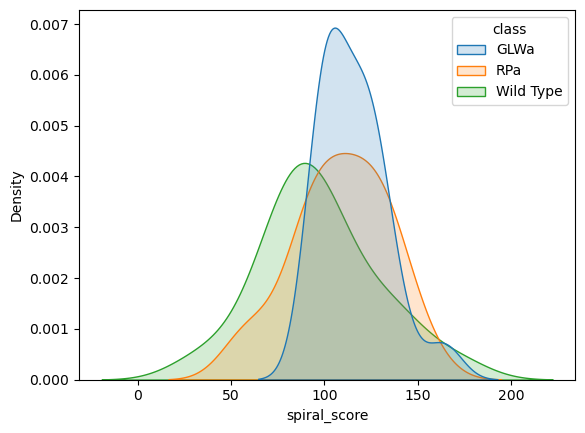

In [15]:
sns.kdeplot(data = df, x = "spiral_score", hue = "class", fill = True, alpha = 0.2)

In [28]:
df_counts = df.groupby(["class", "movement_type"]).count()
df_counts = df_counts["spiral_score"]
df_counts

class      movement_type
GLWa       Nonmover          1
           Spiraler         16
           Traveler          3
RPa        Nonmover          3
           Spiraler         13
           Traveler          4
Wild Type  Nonmover         12
           Spiraler          8
Name: spiral_score, dtype: int64

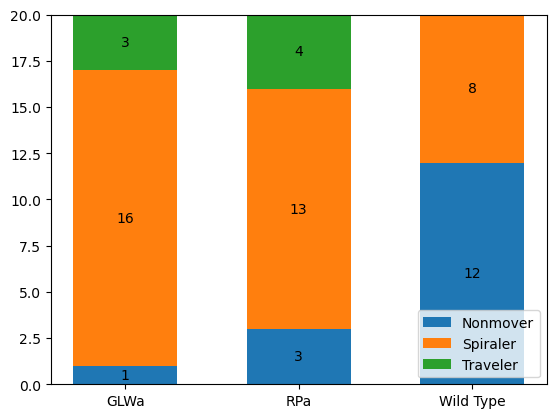

In [29]:
classes = ('GLWa', 'RPa', "Wild Type")
movement_counts = {
    'Nonmover': np.array([1, 3, 12]),
    'Spiraler': np.array([16, 13, 8]),
    'Traveler': np.array([3, 4, 0])
}
width = 0.6  # the width of the bars: can also be len(x) sequence

fig, ax = plt.subplots()
bottom = np.zeros(3)

for c, c_count in movement_counts.items():
    p = ax.bar(classes, c_count, width, label=c, bottom=bottom)
    bottom += c_count

    ax.bar_label(p, label_type='center')

ax.legend()

plt.show()